In [1]:
pip install geopandas shapely fastkml


     ---------------------------------------- 0.0/51.5 kB ? eta -:--:--
     ------- -------------------------------- 10.2/51.5 kB ? eta -:--:--
     --------------- ---------------------- 20.5/51.5 kB 162.5 kB/s eta 0:00:01
     ------------------------------ ------- 41.0/51.5 kB 245.8 kB/s eta 0:00:01
     -------------------------------------- 51.5/51.5 kB 263.0 kB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.1 MB 435.7 kB/s eta 0:00:03
   - -------------------------------------- 0.0/1.1 MB 326.8 kB/s eta 0:00:04
   -- ------------------------------------- 0.1/1.1 MB 363.1 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.1 MB 363.1 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.1 MB 350.1 kB


[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip



1. **Imports**: The code imports several Python libraries, including `random`, `uuid`, `pandas`, `datetime`, `shapely`, and `fastkml`. These libraries are used for various tasks throughout the code.

2. **Load KML file and extract polygon**: The code reads a KML file (a file format used to represent geographic data) named "UAE polygon.kml" and extracts the polygon geometry representing the UAE. The `shapely.geometry.shape()` function is used to convert the KML polygon into a `Shapely` polygon object.

3. **Get bounds of the polygon**: The code retrieves the bounding box coordinates (minimum and maximum latitude and longitude) of the extracted polygon.

4. **Generate random points within the polygon bounds**: The `generate_random_point_within_bounds()` function generates random latitude and longitude coordinates within the bounding box of the polygon. The function ensures that the generated points are within the polygon by using the `shapely.geometry.Point.within()` method.

5. **Set parameters**: The code defines several parameters, including the number of sensors, the number of readings per sensor, the time interval between readings, and the total number of points to generate.

6. **Generate sensor IDs**: The code generates a list of unique UUIDs (Universally Unique Identifiers) to represent the sensor IDs.

7. **Generate timestamps**: The code generates a list of timestamps, starting from the current time (with minutes and seconds set to 0) and incrementing by the specified interval (5 minutes).

8. **Generate and check random points within the polygon**: The code generates random points within the polygon bounds and checks if each point is contained within the polygon using the `shapely.geometry.Polygon.contains()` method. The points that are within the polygon are added to the `inside_points` list.

9. **Create DataFrame**: The code creates a pandas DataFrame with the generated data, including the sensor ID, timestamp, longitude, and latitude for each reading.

10. **Display the first 20 rows of the DataFrame**: The last line of the code displays the first 20 rows of the generated DataFrame.

 this code generates a dataset of sensor readings within the geographic area of the UAE. The sensor readings are distributed randomly within the polygon representing the UAE, and the data is organized into a pandas DataFrame for further analysis.


### Imports
```python
import random
import uuid
import pandas as pd
from datetime import datetime, timedelta
from shapely.geometry import Point, shape
from fastkml import kml
```
- `random`: Provides functions for generating random numbers.
- `uuid`: Generates unique identifiers (UUIDs).
- `pandas`: A library for data manipulation and analysis.
- `datetime`, `timedelta`: For handling dates and times.
- `shapely.geometry`: Used for geometric operations.
- `fastkml`: Handles KML files, which are used to store geographic data.

### Load and Extract Polygon from KML File
```python
k = kml.KML()
with open('UAE polygon.kml', 'rb') as f:
    k.from_string(f.read())

features = list(k.features())
placemarks = list(features[0].features())
polygon_geom = placemarks[0].geometry
shapely_polygon = shape(polygon_geom)
```
1. **Create a KML object**: `kml.KML()` initializes a new KML object.
2. **Read the KML file**: Opens the file `'UAE polygon.kml'` in binary mode and reads its contents.
3. **Parse KML contents**: The `k.from_string(f.read())` method reads the KML data into the `KML` object.
4. **Extract features**: `k.features()` gets all the features in the KML file. The first feature is expected to be the polygon.
5. **Get the polygon geometry**: Extracts the geometry of the first placemark.
6. **Convert to Shapely Polygon**: `shape(polygon_geom)` converts the geometry to a Shapely polygon object for geometric operations.

### Get Polygon Bounds
```python
bounds = shapely_polygon.bounds
```
- **Bounding Box**: `shapely_polygon.bounds` returns the bounds of the polygon as a tuple `(min_lon, min_lat, max_lon, max_lat)`.

### Function to Generate Random Points Within Bounds
```python
def generate_random_point_within_bounds(bounds):
    min_lon, min_lat, max_lon, max_lat = bounds
    lon = random.uniform(min_lon, max_lon)
    lat = random.uniform(min_lat, max_lat)
    return lon, lat
```
- **Generate Coordinates**: Uses the bounds to generate random latitude and longitude values within the specified rectangle.

### Parameters
```python
num_sensors = 1000
num_readings_per_sensor = 12
interval = 5
num_points = 12000
```
- **`num_sensors`**: Number of sensors to simulate.
- **`num_readings_per_sensor`**: Number of readings each sensor takes.
- **`interval`**: Time interval between readings in minutes.
- **`num_points`**: Total number of data points to generate (12000).

### Generate UUIDs for Each Sensor
```python
sensor_ids = [str(uuid.uuid4()) for _ in range(num_sensors)]
```
- **UUIDs**: Generates a unique UUID for each sensor.

### Generate Timestamps
```python
start_time = datetime.now().replace(minute=0, second=0, microsecond=0)
timestamps = [start_time + timedelta(minutes=i * interval) for i in range(num_readings_per_sensor)]
```
- **Start Time**: Sets the starting time to the current time with minutes, seconds, and microseconds set to zero.
- **Generate Timestamps**: Creates a list of timestamps spaced by the `interval` (5 minutes).

### Generate and Check Random Points Within the Polygon
```python
inside_points = []

while len(inside_points) < num_points:
    lon, lat = generate_random_point_within_bounds(bounds)
    point = Point(lon, lat)
    if shapely_polygon.contains(point):
        inside_points.append((lon, lat))
```
- **Initialize List**: `inside_points` will hold points that lie within the polygon.
- **Generate Points**: Continuously generate random points and check if they are inside the polygon.
- **Add Points**: If a point is inside, it is added to the `inside_points` list.

### Create DataFrame
```python
data = []
for sensor_id in sensor_ids:
    for timestamp in timestamps:
        lon, lat = inside_points.pop(0)  # Get a point from the list
        data.append({'SensorID': sensor_id, 'Timestamp': timestamp, 'Longitude': lon, 'Latitude': lat})
```
- **Initialize Data List**: `data` will store the sensor data.
- **Populate Data**: For each sensor and timestamp, take a point from `inside_points` and create a dictionary with sensor ID, timestamp, longitude, and latitude. This dictionary is appended to the `data` list.

### Convert to DataFrame
```python
df = pd.DataFrame(data)
```
- **Create DataFrame**: Converts the list of dictionaries to a Pandas DataFrame.

The resulting DataFrame `df` contains columns for `SensorID`, `Timestamp`, `Longitude`, and `Latitude`, with 12,000 data points.

In [53]:
import random
import uuid
import pandas as pd
from datetime import datetime, timedelta
from shapely.geometry import Point, shape
from fastkml import kml

# Load the KML file and extract the polygon
k = kml.KML()
with open('UAE polygon.kml', 'rb') as f: 
    k.from_string(f.read())

features = list(k.features())
placemarks = list(features[0].features())
polygon_geom = placemarks[0].geometry
shapely_polygon = shape(polygon_geom)

# Get bounds of the polygon
bounds = shapely_polygon.bounds

def generate_random_point_within_bounds(bounds):
    min_lon, min_lat, max_lon, max_lat = bounds
    lon = random.uniform(min_lon, max_lon)
    lat = random.uniform(min_lat, max_lat)
    return lon, lat

# Parameters
num_sensors = 1000
interval = 5  # minutes
num_readings_per_sensor = 24 * 60 // interval  # Number of readings per sensor for a full day
num_points = num_sensors * num_readings_per_sensor  # Total number of points to generate

# Generate UUIDs for each sensor
sensor_ids = [str(uuid.uuid4()) for _ in range(num_sensors)]

# Generate timestamps for a full day
start_time = datetime.now().replace(minute=0, second=0, microsecond=0)
timestamps = [start_time + timedelta(minutes=i * interval) for i in range(num_readings_per_sensor)]

# Generate and check random points within the polygon
inside_points = []

while len(inside_points) < num_points:
    lon, lat = generate_random_point_within_bounds(bounds)
    point = Point(lon, lat)
    if shapely_polygon.contains(point):
        inside_points.append((lon, lat))

# Create DataFrame
data = []
for sensor_id in sensor_ids:
    for timestamp in timestamps:
        lon, lat = inside_points.pop(0)  # Get a point from the list
        data.append({'SensorID': sensor_id, 'Timestamp': timestamp, 'Longitude': lon, 'Latitude': lat})

# Convert to DataFrame
df = pd.DataFrame(data)
df.head(20) # Display the first 20 rows


,SensorID,Timestamp,Longitude,Latitude
0,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:00:00,56.359187,25.994868
1,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:05:00,55.032050,23.915024
2,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:10:00,55.412287,24.050280
3,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:15:00,54.418152,24.465998
4,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:20:00,54.564432,24.592212
5,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:25:00,53.514115,23.893113
6,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:30:00,52.156293,23.985580
7,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:35:00,54.822297,23.753564
8,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:40:00,55.083265,23.813423
9,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:45:00,55.352782,23.439883


- 288,000 rows: This is because we have 1,000 sensors, each generating 288 readings for a full day.
- 4 columns: These are SensorID, Timestamp, Longitude, and Latitude.

In [55]:
df.shape

(288000, 4)


### Explanation:
1. **Temperature Generation:**
   - **In-range:** 90% of temperatures are generated between 1 and 10.
   - **Out-of-range:** 10% of temperatures are generated either below 1 or above 10.

2. **Shuffling:**
   - After generating the temperatures, they are shuffled to ensure randomness in their distribution across the DataFrame.

3. **Adding to DataFrame:**
   - The `Temperature` column is added to the existing DataFrame.


In [56]:
import random

# Function to generate temperature values
def generate_temperature(num_rows, out_of_range_percentage=10):
    temperatures = []
    num_out_of_range = int(num_rows * out_of_range_percentage / 100)
    num_in_range = num_rows - num_out_of_range

    # Generate in-range temperatures (1 to 10)
    for _ in range(num_in_range):
        temperatures.append(random.uniform(1, 10))

    # Generate out-of-range temperatures (<1 or >10)
    for _ in range(num_out_of_range):
        if random.random() < 0.5:
            temperatures.append(random.uniform(-10, 0))  # Below 1
        else:
            temperatures.append(random.uniform(11, 20))  # Above 10

    # Shuffle the temperatures to randomize their order
    random.shuffle(temperatures)
    
    return temperatures

# Add temperature to the DataFrame
df['Temperature'] = generate_temperature(len(df))

# Display the first 20 rows with temperature
df.head(20)


,SensorID,Timestamp,Longitude,Latitude,Temperature
0,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:00:00,56.359187,25.994868,4.465445
1,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:05:00,55.032050,23.915024,16.114049
2,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:10:00,55.412287,24.050280,6.794008
3,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:15:00,54.418152,24.465998,8.243666
4,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:20:00,54.564432,24.592212,4.454575
5,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:25:00,53.514115,23.893113,2.640611
6,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:30:00,52.156293,23.985580,7.332699
7,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:35:00,54.822297,23.753564,4.710080
8,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:40:00,55.083265,23.813423,5.866791
9,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:45:00,55.352782,23.439883,2.654082


In [57]:
# Count temperatures within the range 1-10
in_range_count = df[(df['Temperature'] >= 1) & (df['Temperature'] <= 10)].shape[0]

# Count temperatures outside the range 1-10
out_of_range_count = df[(df['Temperature'] < 1) | (df['Temperature'] > 10)].shape[0]

# Print the counts
print(f"Number of temperatures between 1-10: {in_range_count}")
print(f"Number of temperatures outside 1-10: {out_of_range_count}")


Number of temperatures between 1-10: 259200
Number of temperatures outside 1-10: 28800



### Explanation:
1. **Mapping SensorID to Company Name:**
   - A dictionary (`sensor_to_company`) maps each unique `SensorID` to a single, randomly chosen company name.
   - The `map` function is then used to apply this mapping to the `Company` column in the DataFrame.

2. **Consistency:**
   - This ensures that each `SensorID` has the same company name across all its readings.



In [58]:
import random

# List of sample company names
company_names = [
    "AgroFresh", "GreenHarvest", "FarmFoods", "Nature's Best", "FreshDelight",
    "OrganicGrowers", "VeggieLand", "FruitKing", "EcoHarvest", "PureOrganics"
]

# Function to assign the same company name to each SensorID
def assign_company_names_per_sensor(sensor_ids, company_list):
    sensor_to_company = {sensor_id: random.choice(company_list) for sensor_id in sensor_ids}
    return df['SensorID'].map(sensor_to_company)

# Assign company names based on SensorID
df['Company'] = assign_company_names_per_sensor(df['SensorID'].unique(), company_names)

# Display the first 20 rows with company names
df.head(20)

,SensorID,Timestamp,Longitude,Latitude,Temperature,Company
0,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:00:00,56.359187,25.994868,4.465445,AgroFresh
1,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:05:00,55.032050,23.915024,16.114049,AgroFresh
2,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:10:00,55.412287,24.050280,6.794008,AgroFresh
3,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:15:00,54.418152,24.465998,8.243666,AgroFresh
4,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:20:00,54.564432,24.592212,4.454575,AgroFresh
5,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:25:00,53.514115,23.893113,2.640611,AgroFresh
6,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:30:00,52.156293,23.985580,7.332699,AgroFresh
7,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:35:00,54.822297,23.753564,4.710080,AgroFresh
8,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:40:00,55.083265,23.813423,5.866791,AgroFresh
9,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:45:00,55.352782,23.439883,2.654082,AgroFresh


In [59]:
# Display the first 20 rows with company names
df.head(20)

,SensorID,Timestamp,Longitude,Latitude,Temperature,Company
0,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:00:00,56.359187,25.994868,4.465445,AgroFresh
1,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:05:00,55.032050,23.915024,16.114049,AgroFresh
2,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:10:00,55.412287,24.050280,6.794008,AgroFresh
3,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:15:00,54.418152,24.465998,8.243666,AgroFresh
4,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:20:00,54.564432,24.592212,4.454575,AgroFresh
5,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:25:00,53.514115,23.893113,2.640611,AgroFresh
6,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:30:00,52.156293,23.985580,7.332699,AgroFresh
7,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:35:00,54.822297,23.753564,4.710080,AgroFresh
8,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:40:00,55.083265,23.813423,5.866791,AgroFresh
9,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:45:00,55.352782,23.439883,2.654082,AgroFresh


In [60]:
df.tail(20)

,SensorID,Timestamp,Longitude,Latitude,Temperature,Company
287980,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 07:20:00,53.732743,24.168587,1.638248,FarmFoods
287981,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 07:25:00,54.979836,23.115958,8.739488,FarmFoods
287982,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 07:30:00,54.739192,23.308911,9.593765,FarmFoods
287983,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 07:35:00,55.434807,25.369906,2.237410,FarmFoods
287984,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 07:40:00,54.976478,22.847595,18.019767,FarmFoods
287985,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 07:45:00,55.557152,24.179929,3.390911,FarmFoods
287986,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 07:50:00,56.129030,25.909173,9.963307,FarmFoods
287987,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 07:55:00,54.974558,22.729705,6.790939,FarmFoods
287988,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:00:00,56.217708,25.705633,9.627213,FarmFoods
287989,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:05:00,53.357581,23.784870,3.043353,FarmFoods


In [62]:
df.to_csv('generating data full day.csv', index=False)

In [61]:
df.shape

(288000, 6)

In [8]:
import pandas as pd

In [44]:
df = pd.read_csv("generating data full day.csv")

In [45]:
df

,SensorID,Timestamp,Longitude,Latitude,Temperature,Company
0,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:00:00,56.359187,25.994868,4.465445,AgroFresh
1,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:05:00,55.032050,23.915024,16.114049,AgroFresh
2,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:10:00,55.412287,24.050280,6.794008,AgroFresh
3,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:15:00,54.418152,24.465998,8.243666,AgroFresh
4,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:20:00,54.564432,24.592212,4.454575,AgroFresh
...,...,...,...,...,...,...
287995,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:35:00,56.287398,25.376227,8.871833,FarmFoods
287996,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:40:00,55.757265,25.419591,3.396522,FarmFoods
287997,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:45:00,52.887266,23.324574,6.946225,FarmFoods
287998,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:50:00,54.715901,23.357380,6.985238,FarmFoods


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   SensorID     288000 non-null  object 
 1   Timestamp    288000 non-null  object 
 2   Longitude    288000 non-null  float64
 3   Latitude     288000 non-null  float64
 4   Temperature  288000 non-null  float64
 5   Company      288000 non-null  object 
dtypes: float64(3), object(3)
memory usage: 13.2+ MB


In [47]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [48]:
df['Minute'] = df['Timestamp'].dt.minute
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month

In [49]:
df

,SensorID,Timestamp,Longitude,Latitude,Temperature,Company,Minute,Hour,Day,Month
0,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:00:00,56.359187,25.994868,4.465445,AgroFresh,0,9,3,9
1,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:05:00,55.032050,23.915024,16.114049,AgroFresh,5,9,3,9
2,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:10:00,55.412287,24.050280,6.794008,AgroFresh,10,9,3,9
3,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:15:00,54.418152,24.465998,8.243666,AgroFresh,15,9,3,9
4,f81d0c7e-5896-4e30-becd-a20f19b47dd8,2024-09-03 09:20:00,54.564432,24.592212,4.454575,AgroFresh,20,9,3,9
...,...,...,...,...,...,...,...,...,...,...
287995,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:35:00,56.287398,25.376227,8.871833,FarmFoods,35,8,4,9
287996,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:40:00,55.757265,25.419591,3.396522,FarmFoods,40,8,4,9
287997,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:45:00,52.887266,23.324574,6.946225,FarmFoods,45,8,4,9
287998,729b35f4-7135-4528-9d5e-28db438f0b1e,2024-09-04 08:50:00,54.715901,23.357380,6.985238,FarmFoods,50,8,4,9


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   SensorID     288000 non-null  object        
 1   Timestamp    288000 non-null  datetime64[ns]
 2   Longitude    288000 non-null  float64       
 3   Latitude     288000 non-null  float64       
 4   Temperature  288000 non-null  float64       
 5   Company      288000 non-null  object        
 6   Minute       288000 non-null  int64         
 7   Hour         288000 non-null  int64         
 8   Day          288000 non-null  int64         
 9   Month        288000 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(2)
memory usage: 22.0+ MB


In [58]:
# 1. Temperature Analysis
def temperature_analysis(df):
    temp_stats = df.groupby('SensorID')['Temperature'].agg(['mean', 'min', 'max'])
    print(temp_stats.describe())
    
    # Identify sensors outside acceptable range (assuming 0-10°C is acceptable)
    out_of_range = df[(df['Temperature'] < 0) | (df['Temperature'] > 10)]['SensorID'].unique()
    print(f"Sensors with readings outside 0-5°C: {out_of_range}")
temperature_analysis(df)

              mean          min          max
count  1000.000000  1000.000000  1000.000000
mean      5.461860    -9.328714    19.372198
std       0.236835     0.610232     0.604726
min       4.745751    -9.999905    14.055087
25%       5.300223    -9.767302    19.109254
50%       5.457121    -9.497151    19.537285
75%       5.622651    -9.069548    19.816982
max       6.287965    -6.539499    19.999924
Sensors with readings outside 0-5°C: ['f81d0c7e-5896-4e30-becd-a20f19b47dd8'
 '374f6062-af2c-4ce5-b02d-81be3a7a1ec0'
 'f8e8502b-444d-4573-aab9-93bfd670a1e9'
 '7b87c03c-64aa-4f42-9e0d-2f7b3fa4e15b'
 '7eebab20-eb28-479e-8a79-f00911c9910c'
 '680e2e6a-eed1-47b9-a61b-cd91a8a33de5'
 '53c4bb64-9e38-4899-9d5b-c7a90f719a28'
 '6e8a9d81-de96-4751-97b5-698088ab6d7f'
 '0e133b4e-05ff-410f-81fc-48ab5c71576c'
 'a44d4eb2-be04-44c2-8c2b-3413983aeb09'
 '462c25d3-2c98-41df-9bf7-98832c48a317'
 'dc81d351-5a96-4051-8570-39e37a53a526'
 '7055f93e-fa21-42b9-8ef8-75c11b5b843c'
 '96a488a2-a9aa-43b4-a597-06f93147fde5

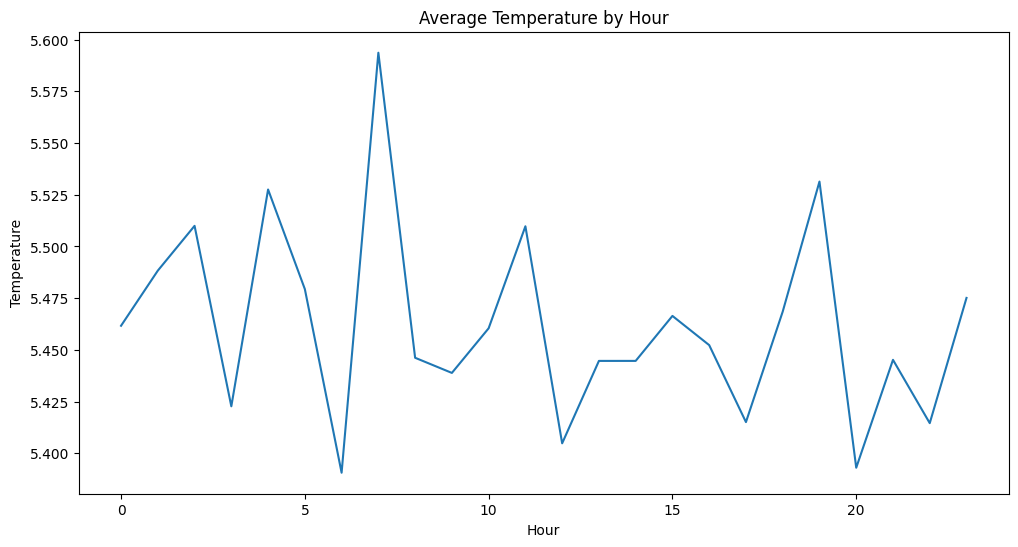

In [61]:
import matplotlib.pyplot as plt
# 2. Temporal Patterns
def temporal_patterns(df):
    hourly_temp = df.groupby('Hour')['Temperature'].mean()
    plt.figure(figsize=(12, 6))
    hourly_temp.plot()
    plt.title('Average Temperature by Hour')
    plt.xlabel('Hour')
    plt.ylabel('Temperature')
    plt.show()

temporal_patterns(df)


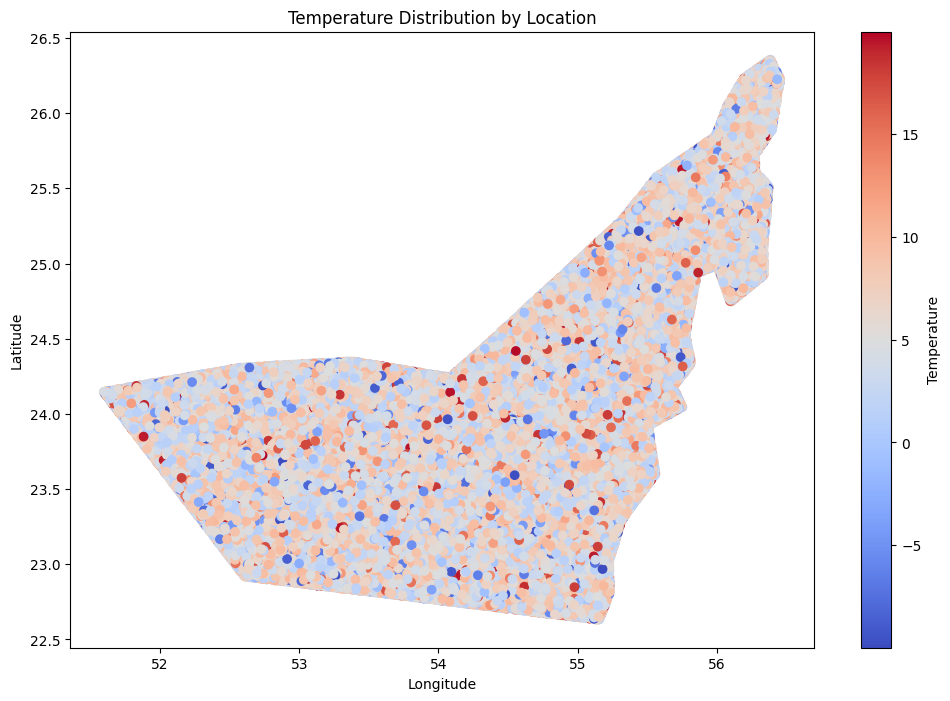

In [62]:
# 3. Geospatial Analysis
def geospatial_analysis(df):
    plt.figure(figsize=(12, 8))
    plt.scatter(df['Longitude'], df['Latitude'], c=df['Temperature'], cmap='coolwarm')
    plt.colorbar(label='Temperature')
    plt.title('Temperature Distribution by Location')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()
geospatial_analysis(df)
